In [1]:
import pandas as pd


def reshape_results_to_wide_format(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transforms a long-format DataFrame of results into a wide-format DataFrame.

    The resulting DataFrame will have 'method' as the index, and a single column
    for each combination of 'dataset' and 'metric'.

    Args:
        df (pd.DataFrame): A DataFrame with columns ['method', 'dataset', 'metric', 'value'].

    Returns:
        pd.DataFrame: The reshaped, wide-format DataFrame.
    """
    pivoted_df = df.pivot_table(
        index='method',
        columns=['dataset', 'metric'],
        values='value'
    )

    pivoted_df.columns = [f"{col[0]}_{col[1]}" for col in pivoted_df.columns]
    return pivoted_df

In [2]:
import pickle
import numpy as np

rf_datasets = {
    'Linear': 'synthetic_data/herg_ecfp_linear',
    'Piecewise': 'synthetic_data/herg_ecfp_piecewise',
    'Polynomial': 'synthetic_data/herg_ecfp_nonlinear',
    'CNOHF': 'cnohf_data/cnohf_ecfp',
    'COF': 'cof_data/cof_ecfp_descriptor',
    'Photoswitch': 'photoswitch_data/photoswitch_ecfp',
    'Polymers': 'polymers_data/polymers_ecfp',
    'Redox': 'redox_data/redox_ecfp',
}

pred_models_results = {
    'Dataset': [],
    'RMSE': [],
    'RMSE std': [],
    'SMAPE': [],
    'SMAPE std': [],
    'PA': [],
    'PA std': [],
}

for dname, dataset in rf_datasets.items():
    with open(f'../results/{dataset}/results.pickle', 'rb') as f:
        results = pickle.load(f)
    pred_models_results['Dataset'].append(dname)

    m_mean = {}
    m_std = {}
    for method in results['scores']:
        m_mean[method] = [np.mean(results['scores'][method])]
        m_std[method] = [np.std(results['scores'][method])]
    pred_models_results['RMSE'].append(m_mean['rmse'][0])
    pred_models_results['RMSE std'].append(m_std['rmse'][0])
    pred_models_results['SMAPE'].append(m_mean['smape'][0])
    pred_models_results['SMAPE std'].append(m_std['smape'][0])
    pred_models_results['PA'].append(m_mean['pairwise_accuracy_score'][0])
    pred_models_results['PA std'].append(m_std['pairwise_accuracy_score'][0])

df_pred = pd.DataFrame(pred_models_results)

mean_cols = ['RMSE', 'SMAPE', 'PA']
std_cols = ['RMSE std', 'SMAPE std', 'PA std']
df_mean_str = df_pred[mean_cols].map('{:.2f}'.format)
df_std_str = df_pred[std_cols].map('{:.2f}'.format)
df_std_str.rename(columns={
    'RMSE std': 'RMSE',
    'SMAPE std': 'SMAPE',
    'PA std': 'PA',
}, inplace=True)

df_pred_str = df_mean_str + '(' + df_std_str + ')'
df_pred_str.insert(0, 'Dataset', df_pred['Dataset'])
df_pred_str

df_pred_str.set_index('Dataset', inplace=True)

print(df_pred_str.style.format(precision=2).to_latex())


\begin{tabular}{llll}
 & RMSE & SMAPE & PA \\
Dataset &  &  &  \\
Linear & 3.78(0.67) & 0.10(0.03) & 0.96(0.01) \\
Piecewise & 1.17(0.89) & 0.18(0.08) & 0.99(0.00) \\
Polynomial & 4.30(1.40) & 0.39(0.09) & 0.93(0.03) \\
CNOHF & 0.39(0.08) & 0.04(0.00) & 0.83(0.03) \\
COF & 182.91(28.28) & 0.62(0.05) & 0.66(0.10) \\
Photoswitch & 24.58(5.87) & 0.04(0.01) & 0.88(0.02) \\
Polymers & 38.80(11.36) & 0.09(0.02) & 0.83(0.05) \\
Redox & 29.65(21.25) & 0.07(0.05) & 0.90(0.06) \\
\end{tabular}



In [3]:
gt_datasets = {
    'GT Linear': 'gt_synthetic_data/herg_ecfp_linear',
    'GT Piecewise': 'gt_synthetic_data/herg_ecfp_piecewise',
    'GT Polynomial': 'gt_synthetic_data/herg_ecfp_nonlinear',
}

metrics = {}
cf_validity = {}
cf_similarity = {}

for dname, dataset in gt_datasets.items():
    with open(f'../results/{dataset}/explanations/analysis/metrics_results.pickle', 'rb') as f:
        results = pickle.load(f)
    metrics[dname] = results
    with open(f'../results/{dataset}/explanations/analysis/cf_validity_results.pickle', 'rb') as f:
        results = pickle.load(f)
    cf_validity[dname] = results
    with open(f'../results/{dataset}/explanations/analysis/cf_similarity_results.pickle', 'rb') as f:
        results = pickle.load(f)
    cf_similarity[dname] = results

for dname, dataset in rf_datasets.items():
    try:
        with open(f'../results/{dataset}/explanations/analysis4/metrics_results.pickle', 'rb') as f:
            results = pickle.load(f)
        metrics[dname] = results
        with open(f'../results/{dataset}/explanations/analysis4/cf_validity_results.pickle', 'rb') as f:
            results = pickle.load(f)
        cf_validity[dname] = results
        with open(f'../results/{dataset}/explanations/analysis4/cf_similarity_results.pickle', 'rb') as f:
            results = pickle.load(f)
        cf_similarity[dname] = results
    except:
        print(f"Results not found for dataset: {dname}")
metrics

{'GT Linear': {'lime': {'pgi_mean': np.float64(13.281199351491571),
   'pgu_mean': np.float64(0.007629546044098573),
   'pgi_std': np.float64(0.19512061066314867),
   'pgu_std': np.float64(0.00018306654696987305),
   'fa_mean': np.float64(1.0),
   'fa_std': np.float64(0.0),
   'fa_interactions_mean': None,
   'fa_interactions_std': None},
  'shap': {'pgi_mean': np.float64(13.281126251621274),
   'pgu_mean': np.float64(0.0077144747081712055),
   'pgi_std': np.float64(0.19510037506066524),
   'pgu_std': np.float64(0.00020015003599456346),
   'fa_mean': np.float64(1.0),
   'fa_std': np.float64(0.0),
   'fa_interactions_mean': None,
   'fa_interactions_std': None},
  'shapiq1': {'pgi_mean': np.float64(13.281153904020755),
   'pgu_mean': np.float64(0.007703942931258106),
   'pgi_std': np.float64(0.1950905219856763),
   'pgu_std': np.float64(0.00019014023174869285),
   'fa_mean': np.float64(1.0),
   'fa_std': np.float64(0.0),
   'fa_interactions_mean': None,
   'fa_interactions_std': None},


In [4]:
df_validity = {'method': [], 'dataset': [], 'metric': [], 'value': []}
for k in cf_validity:
    for method in cf_validity[k]:
        df_validity['method'].append(method)
        df_validity['dataset'].append(k)
        df_validity['metric'].append('validity')
        df_validity['value'].append(cf_validity[k][method])
df_validity = pd.DataFrame(df_validity)
df_validity = reshape_results_to_wide_format(df_validity)

df_validity = df_validity.T
df_validity.index = [c.replace('_validity', '') for c in df_validity.index]
df_validity = df_validity[['mmace', 'meg']]
print(df_validity.style.format(precision=2).to_latex())

\begin{tabular}{lrr}
method & mmace & meg \\
CNOHF & 1.00 & 0.55 \\
COF & 0.64 & 0.33 \\
GT Linear & 0.65 & 0.65 \\
GT Piecewise & 0.61 & 0.76 \\
GT Polynomial & 0.75 & 0.69 \\
Linear & 0.67 & 0.68 \\
Photoswitch & 0.91 & 0.84 \\
Piecewise & 0.80 & 0.74 \\
Polymers & 0.78 & 0.50 \\
Polynomial & 0.86 & 0.72 \\
Redox & 0.66 & 0.61 \\
\end{tabular}



In [5]:
df_similarity = {'method': [], 'dataset': [], 'metric': [], 'value': []}
for k in cf_similarity:
    for method in cf_similarity[k]:
        for i, m in enumerate(['similarity', 'similarity std']):
            df_similarity['dataset'].append(k)
            df_similarity['method'].append(method)
            df_similarity['metric'].append(m)
            df_similarity['value'].append(cf_similarity[k][method][i])
df_similarity = pd.DataFrame(df_similarity)
df_similarity = reshape_results_to_wide_format(df_similarity)
df_similarity_mean = df_similarity[[c for c in df_similarity.columns if 'similarity' in c and 'std' not in c]]
df_similarity_std = df_similarity[[c for c in df_similarity.columns if 'similarity std' in c]]
df_similarity_std.rename(columns={d: d.replace('similarity std', 'similarity') for d in df_similarity_std.columns}, inplace=True)

df_mean_str = df_similarity_mean.map('{:.2f}'.format)
df_std_str = df_similarity_std.map('{:.2f}'.format)
df_similarity = df_mean_str + '(' + df_std_str + ')'
df_similarity = df_similarity.T
df_similarity.index = [c.replace('_similarity', '') for c in df_similarity.index]
df_similarity = df_similarity[['mmace', 'meg']]
print(df_similarity.style.format(precision=2).to_latex())

\begin{tabular}{lll}
method & mmace & meg \\
CNOHF & 0.39(0.23) & 0.48(0.14) \\
COF & 0.45(0.21) & 0.62(0.13) \\
GT Linear & 0.44(0.17) & 0.66(0.12) \\
GT Piecewise & 0.49(0.16) & 0.65(0.09) \\
GT Polynomial & 0.39(0.21) & 0.65(0.11) \\
Linear & 0.45(0.17) & 0.67(0.11) \\
Photoswitch & 0.36(0.19) & 0.54(0.12) \\
Piecewise & 0.43(0.18) & 0.65(0.09) \\
Polymers & 0.26(0.15) & 0.38(0.16) \\
Polynomial & 0.46(0.19) & 0.65(0.11) \\
Redox & 0.34(0.16) & 0.45(0.08) \\
\end{tabular}



/tmp/ipykernel_1242693/830371422.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_similarity_std.rename(columns={d: d.replace('similarity std', 'similarity') for d in df_similarity_std.columns}, inplace=True)


In [6]:
def get_metrics(datasets, metrics_dict, metrics):
    metrics_dataframe = {'method': [], 'dataset': [], 'metric': [], 'value': []}

    for dataset in datasets:
        for method, method_results in metrics[dataset].items():
            for i, m in enumerate(metrics_dict):
                 metrics_dataframe['dataset'].append(dataset)
                 metrics_dataframe['method'].append(method)
                 metrics_dataframe['metric'].append(m)
                 metrics_dataframe['value'].append(method_results[m])
    metrics_dataframe = pd.DataFrame(metrics_dataframe)
    metrics_dataframe = reshape_results_to_wide_format(metrics_dataframe)

    metrics_df_mean = metrics_dataframe[[
        c for c in metrics_dataframe.columns if 'std' not in c
    ]]
    metrics_df_std = metrics_dataframe[[
        c for c in metrics_dataframe.columns if 'std' in c
    ]]

    df_mean_str = metrics_df_mean.map('{:.2f}'.format)
    df_std_str = metrics_df_std.map('{:.2f}'.format)
    df_mean_str.rename(columns={d: d.replace('_mean', '') for d in df_mean_str.columns}, inplace=True)
    df_std_str.rename(columns={d: d.replace('_std', '') for d in df_std_str.columns}, inplace=True)

    # Concatenate the string DataFrames
    # This works element-wise because the index and columns match perfectly
    df_combined = df_mean_str + '(' + df_std_str + ')'
    df_combined.rename(columns={d: d.replace('_', ' ') for d in df_combined.columns
    }, inplace=True)
    metrics_df_mean.rename(columns={d: d.replace('_mean', '') for d in metrics_df_mean.columns}, inplace=True)
    return df_combined, metrics_df_mean.rename(columns={d: d.replace('_', ' ') for d in metrics_df_mean.columns})

In [7]:
# gt results

gt_results = ['GT Linear', 'GT Piecewise', 'GT Polynomial']
metrics_names = ['pgi_mean', 'pgi_std', 'pgu_mean', 'pgu_std', 'fa_mean', 'fa_std']

df_combined, gt_means = get_metrics(gt_results, metrics_names, metrics)
print(df_combined.style.format(precision=3).to_latex())

\begin{tabular}{llllllllll}
 & GT Linear fa & GT Linear pgi & GT Linear pgu & GT Piecewise fa & GT Piecewise pgi & GT Piecewise pgu & GT Polynomial fa & GT Polynomial pgi & GT Polynomial pgu \\
method &  &  &  &  &  &  &  &  &  \\
aggregated_mean & 1.00(0.00) & 13.28(0.20) & 0.01(0.00) & 0.98(0.01) & 10.28(0.33) & 0.12(0.04) & 1.00(0.00) & 9.58(0.43) & 0.01(0.00) \\
aggregated_rra & 1.00(0.00) & 13.28(0.20) & 0.01(0.00) & 0.99(0.00) & 10.34(0.35) & 0.02(0.00) & 1.00(0.00) & 9.58(0.43) & 0.01(0.00) \\
lime & 1.00(0.00) & 13.28(0.20) & 0.01(0.00) & 0.57(0.03) & 7.97(0.31) & 3.39(0.53) & 1.00(0.00) & 9.58(0.43) & 0.02(0.00) \\
meg & 0.97(0.02) & 13.24(0.21) & 0.19(0.11) & 0.97(0.03) & 10.29(0.35) & 0.11(0.03) & 0.98(0.02) & 9.54(0.43) & 0.11(0.05) \\
mmace & 0.99(0.00) & 13.26(0.20) & 0.07(0.01) & 0.99(0.00) & 10.33(0.35) & 0.04(0.01) & 0.99(0.00) & 9.55(0.43) & 0.06(0.01) \\
shap & 1.00(0.00) & 13.28(0.20) & 0.01(0.00) & 1.00(0.00) & 10.35(0.35) & 0.01(0.00) & 1.00(0.00) & 9.58(0.43) & 0

/tmp/ipykernel_1242693/1316097926.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metrics_df_mean.rename(columns={d: d.replace('_mean', '') for d in metrics_df_mean.columns}, inplace=True)


In [8]:
gt_means

,GT Linear fa,GT Linear pgi,GT Linear pgu,GT Piecewise fa,GT Piecewise pgi,GT Piecewise pgu,GT Polynomial fa,GT Polynomial pgi,GT Polynomial pgu
method,,,,,,,,,
aggregated_mean,1.000000,13.280920,0.008198,0.983404,10.277075,0.119658,0.999984,9.581575,0.009271
aggregated_rra,1.000000,13.281007,0.008072,0.994912,10.341829,0.019726,1.000000,9.581606,0.009169
lime,1.000000,13.281199,0.007630,0.572074,7.970391,3.394673,1.000000,9.576537,0.016173
meg,0.968693,13.237393,0.192447,0.968303,10.287469,0.110761,0.981339,9.538251,0.105195
mmace,0.989272,13.264867,0.074542,0.991775,10.329647,0.039130,0.992783,9.551192,0.062936
shap,1.000000,13.281126,0.007714,1.000000,10.348908,0.005423,1.000000,9.580747,0.010165
shapiq1,1.000000,13.281154,0.007704,0.997155,10.347477,0.009729,1.000000,9.581409,0.009387
shapiq2,1.000000,13.281154,0.012703,0.842361,10.348602,0.019452,0.886373,9.580540,0.015583


In [9]:
def plot_pgu_pgi(metrics_mean, datasets, ax):
    methods_params = {
        'LIME': {'marker': 'o', 'color': '#3b4b63', 'size': 100, 'zorder': 5, 'font_weight': 'normal'},
        'SHAP': {'marker': '^', 'color': '#6c4cb6', 'size': 200, 'zorder': 10, 'font_weight': 'normal'},
        'SHAP-IQ-1': {'marker': 'o', 'color': '#3b4b63', 'size': 100, 'zorder': 5, 'font_weight': 'normal'},
        'SHAP-IQ-2': {'marker': 'o', 'color': '#3b4b63', 'size': 100, 'zorder': 5, 'font_weight': 'normal'},
        'MEG': {'marker': 'o', 'color': '#3b4b63', 'size': 100, 'zorder': 5, 'font_weight': 'normal'},
        'MMACE': {'marker': 'o', 'color': '#3b4b63', 'size': 100, 'zorder': 5, 'font_weight': 'normal'},
        'Mean': {'marker': 'D', 'color': '#cfd051', 'size': 200, 'zorder': 10, 'font_weight': 'normal'},
        'RRA': {'marker': '*', 'color': '#cfd051', 'size': 200, 'zorder': 10, 'font_weight': 'normal'},
    }
    rename_methods = {
        'lime': 'LIME',
        'shap': 'SHAP',
        'shapiq1': 'SHAP-IQ-1',
        'shapiq2': 'SHAP-IQ-2',
        'meg': 'MEG',
        'mmace': 'MMACE',
        'aggregated_mean': 'Mean',
        'aggregated_rra': 'RRA'
    }
    jitter_strength = 0.001

    for i, dataset in enumerate(datasets):
        pgu = metrics_mean[f"{dataset} pgu"]
        pgi = metrics_mean[f"{dataset} pgi"]

        pgu.index = pgu.index.map(rename_methods)
        pgi.index = pgi.index.map(rename_methods)

        x_span = pgu.max() - pgu.min()
        y_span = pgi.max() - pgi.min()
        x_span = x_span if x_span > 0 else 1.0
        y_span = y_span if y_span > 0 else 1.0

        for method in pgu.index:
            x = pgu[method] + np.random.uniform(-1, 1) * x_span * jitter_strength
            y = pgi[method] + np.random.uniform(-1, 1) * y_span * jitter_strength
            params = methods_params[method]
            if method in ['SHAP', 'Mean', 'RRA']:
                alpha = 1.0
            else:
                alpha = 0.6
            ax[i].scatter(x, y, marker=params['marker'], c=params['color'], s=params['size'],
                       edgecolors='#3b4b63', linewidth=0.5, zorder=params['zorder'], alpha=alpha)
            ax[i].text(x, y, f"{method}", fontsize=11, fontweight=params['font_weight'], zorder=params['zorder']+1)
    return ax


In [10]:
real_rf_results = ['CNOHF', 'Photoswitch', 'Polymers', 'Redox', 'COF']
metrics_names = ['pgi_mean', 'pgi_std', 'pgu_mean', 'pgu_std']
df_combined, _ = get_metrics(real_rf_results, metrics_names, metrics)
df_combined = df_combined[[
    'CNOHF pgi', 'CNOHF pgu',
    'Photoswitch pgi', 'Photoswitch pgu',
    'Polymers pgi', 'Polymers pgu',
    'Redox pgi', 'Redox pgu',
    'COF pgi', 'COF pgu',
]]
print(df_combined.style.format(precision=3).to_latex())

\begin{tabular}{lllllllllll}
 & CNOHF pgi & CNOHF pgu & Photoswitch pgi & Photoswitch pgu & Polymers pgi & Polymers pgu & Redox pgi & Redox pgu & COF pgi & COF pgu \\
method &  &  &  &  &  &  &  &  &  &  \\
aggregated_mean & 0.29(0.02) & 0.04(0.01) & 20.72(4.69) & 1.89(0.57) & 32.06(7.00) & 1.79(0.60) & 41.65(4.27) & 1.03(0.42) & 76.74(33.29) & 6.87(2.08) \\
aggregated_rra & 0.29(0.02) & 0.04(0.00) & 20.79(4.61) & 1.77(0.36) & 32.06(7.06) & 1.71(0.44) & 41.68(4.24) & 1.02(0.60) & 76.22(32.75) & 7.48(3.00) \\
lime & 0.29(0.02) & 0.04(0.01) & 20.78(4.20) & 2.32(0.58) & 32.23(7.10) & 1.66(0.51) & 41.30(4.13) & 1.89(0.38) & 76.52(32.85) & 8.50(2.42) \\
meg & 0.28(0.02) & 0.07(0.01) & 19.20(4.44) & 4.07(0.65) & 31.17(6.50) & 4.06(1.82) & 39.80(4.46) & 4.05(1.54) & 74.55(32.91) & 16.00(3.37) \\
mmace & 0.28(0.02) & 0.05(0.01) & 19.53(4.38) & 3.46(0.65) & 31.67(6.89) & 2.90(0.65) & 40.54(4.25) & 2.89(0.67) & 73.81(30.21) & 13.98(4.49) \\
shap & 0.29(0.02) & 0.03(0.00) & 21.18(4.46) & 1.21(0.1

/tmp/ipykernel_1242693/1316097926.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metrics_df_mean.rename(columns={d: d.replace('_mean', '') for d in metrics_df_mean.columns}, inplace=True)


In [11]:
syn_rf_results = ['Linear', 'Piecewise', 'Polynomial']
metrics_names = ['pgi_mean', 'pgi_std', 'pgu_mean', 'pgu_std']
df_combined, _ = get_metrics(syn_rf_results, metrics_names, metrics)
df_combined = df_combined[[
    'Linear pgi', 'Linear pgu',
    'Piecewise pgi', 'Piecewise pgu',
    'Polynomial pgi', 'Polynomial pgu',
]]
print(df_combined.style.format(precision=3).to_latex())

\begin{tabular}{lllllll}
 & Linear pgi & Linear pgu & Piecewise pgi & Piecewise pgu & Polynomial pgi & Polynomial pgu \\
method &  &  &  &  &  &  \\
aggregated_mean & 11.89(0.30) & 0.11(0.04) & 10.08(0.38) & 0.04(0.01) & 7.95(0.40) & 0.10(0.04) \\
aggregated_rra & 11.90(0.29) & 0.10(0.01) & 10.09(0.38) & 0.04(0.01) & 7.95(0.40) & 0.10(0.04) \\
lime & 11.90(0.29) & 0.19(0.03) & 10.06(0.37) & 0.13(0.04) & 7.92(0.40) & 0.21(0.09) \\
meg & 11.88(0.29) & 0.24(0.04) & 10.01(0.39) & 0.16(0.02) & 7.90(0.40) & 0.20(0.06) \\
mmace & 11.90(0.29) & 0.13(0.03) & 10.08(0.37) & 0.05(0.01) & 7.93(0.40) & 0.13(0.04) \\
shap & 11.91(0.29) & 0.04(0.01) & 10.10(0.38) & 0.01(0.00) & 7.98(0.40) & 0.03(0.01) \\
shapiq1 & 11.46(0.48) & 0.56(0.35) & 9.62(0.46) & 0.54(0.17) & 7.79(0.48) & 0.27(0.19) \\
shapiq2 & 11.43(0.49) & 4.79(2.49) & 9.55(0.47) & 2.88(1.09) & 7.77(0.49) & 1.25(1.13) \\
\end{tabular}



/tmp/ipykernel_1242693/1316097926.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metrics_df_mean.rename(columns={d: d.replace('_mean', '') for d in metrics_df_mean.columns}, inplace=True)


In [12]:
from src.analysis.xai_eval import rank_correlation
from scripts.bulk_metric_compute_gt import convert_term_ranking_to_feature_ranking

gt_datasets = {
    'GT Linear': 'gt_synthetic_data/herg_ecfp_linear',
    'GT Piecewise': 'gt_synthetic_data/herg_ecfp_piecewise',
    'GT Polynomial': 'gt_synthetic_data/herg_ecfp_nonlinear',
}

gt_correlations = {}

for dname, dataset in gt_datasets.items():
    with open(f'../results/{dataset}/explanations/analysis/ranking_per_fold_results.pickle', 'rb') as f:
        results = pickle.load(f)
    pairs_of_ranks = [(key1, key2) for key1 in results.keys() for key2 in results.keys()]
    correla = {}
    for key1, key2 in pairs_of_ranks:
        corrs = []
        for ii in range(len(results[key1])):
            r1 = results[key1][ii]
            r2 = results[key2][ii]
            if 'aggregated' in key1:
                r1 = pd.DataFrame({
                    'features': r1,
                    'abs_ranking': [-v for v in range(1, len(r1) + 1)],
                    'rank': np.arange(1, len(r1) + 1)
                })
            if 'aggregated' in key2:
                r2 = pd.DataFrame({
                    'features': r2,
                    'abs_ranking': [-v for v in range(1, len(r2) + 1)],
                    'rank': np.arange(1, len(r2) + 1)
                })
            rank1 = convert_term_ranking_to_feature_ranking(r1)
            rank2 = convert_term_ranking_to_feature_ranking(r2)
            c = rank_correlation(rank1, rank2, k=4).statistic
            corrs.append(c)
        correlation = np.mean(corrs)
        correla[(key1, key2)] = correlation
    print(dname, dataset)
    gt_correlations[dname] = correla

GT Linear gt_synthetic_data/herg_ecfp_linear
GT Piecewise gt_synthetic_data/herg_ecfp_piecewise
GT Polynomial gt_synthetic_data/herg_ecfp_nonlinear


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.900000,0.800000,-0.135714,-0.078571,0.780000,0.760000,0.760000
RRA,0.900000,1.000000,0.860000,-0.046429,-0.014286,0.840000,0.820000,0.820000
LIME,0.800000,0.860000,1.000000,-0.071429,-0.025000,0.940000,0.960000,0.960000
MEG,-0.135714,-0.046429,-0.071429,1.000000,0.850000,-0.133425,-0.192857,-0.137131
MMACE,-0.078571,-0.014286,-0.025000,0.850000,1.000000,-0.103775,-0.146429,-0.107481
SHAP,0.780000,0.840000,0.940000,-0.133425,-0.103775,1.000000,0.980000,0.980000
SHAP-IQ-1,0.760000,0.820000,0.960000,-0.192857,-0.146429,0.980000,1.000000,1.000000
SHAP-IQ-2,0.760000,0.820000,0.960000,-0.137131,-0.107481,0.980000,1.000000,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,-0.040000,-0.096429,-0.064042,-0.309509,-0.116985,-0.032143,0.038918
RRA,-0.040000,1.000000,0.014286,-0.020798,0.345390,0.383639,0.370000,0.445196
LIME,-0.096429,0.014286,1.000000,-0.096493,-0.241831,-0.148250,-0.110714,0.030359
MEG,-0.064042,-0.020798,-0.096493,1.000000,-0.230656,-0.044509,-0.055438,0.030403
MMACE,-0.309509,0.345390,-0.241831,-0.230656,1.000000,-0.155889,-0.133399,-0.174940
SHAP,-0.116985,0.383639,-0.148250,-0.044509,-0.155889,1.000000,0.910000,1.000000
SHAP-IQ-1,-0.032143,0.370000,-0.110714,-0.055438,-0.133399,0.910000,1.000000,1.000000
SHAP-IQ-2,0.038918,0.445196,0.030359,0.030403,-0.174940,1.000000,1.000000,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.990000,0.410000,-0.074833,-0.263316,0.910000,0.970000,0.989737
RRA,0.990000,1.000000,0.400000,-0.054833,-0.229030,0.920000,0.980000,0.989737
LIME,0.410000,0.400000,1.000000,-0.229369,-0.457852,0.560000,0.440000,0.446491
MEG,-0.074833,-0.054833,-0.229369,1.000000,0.440000,-0.100045,-0.078405,-0.083592
MMACE,-0.263316,-0.229030,-0.457852,0.440000,1.000000,-0.254052,-0.263316,-0.324991
SHAP,0.910000,0.920000,0.560000,-0.100045,-0.254052,1.000000,0.940000,0.929737
SHAP-IQ-1,0.970000,0.980000,0.440000,-0.078405,-0.263316,0.940000,1.000000,0.969737
SHAP-IQ-2,0.989737,0.989737,0.446491,-0.083592,-0.324991,0.929737,0.969737,1.000000


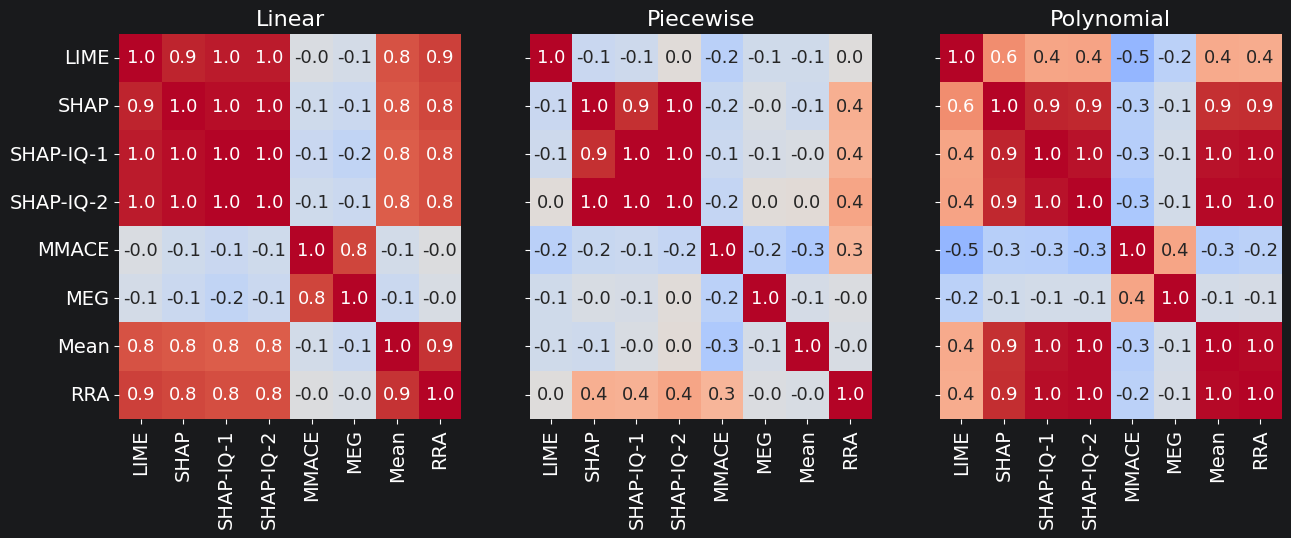

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
name_data_mapping = {
    'GT Linear': 'Linear',
    'GT Piecewise': 'Piecewise',
    'GT Polynomial': 'Polynomial'
}
order_mapping = {
    'GT Linear': 0,
    'GT Piecewise': 1,
    'GT Polynomial': 2
}
methods_mapping = {
    'lime': 'LIME',
    'shap': 'SHAP',
    'shapiq1': 'SHAP-IQ-1',
    'shapiq2': 'SHAP-IQ-2',
    'meg': 'MEG',
    'mmace': 'MMACE',
    'aggregated_mean': 'Mean',
    'aggregated_rra': 'RRA'
}
methods_order = ['LIME', 'SHAP', 'SHAP-IQ-1', 'SHAP-IQ-2', 'MMACE', 'MEG', 'Mean', 'RRA']
plt.style.use('default')
for i, (key, data) in enumerate(gt_correlations.items()):
    if key not in name_data_mapping:
        continue
    s = pd.Series(data)
    correlation_matrix = s.unstack()
    renamed_matrix = correlation_matrix.rename(index=methods_mapping, columns=methods_mapping)
    display(renamed_matrix)
    renamed_matrix = renamed_matrix[methods_order].loc[methods_order]
    mappable = sns.heatmap(renamed_matrix, annot=True, fmt=".1f", ax=ax[order_mapping[key]], cmap='coolwarm', vmin=-1, vmax=1, cbar=False, annot_kws={'size': 13})

    ax[order_mapping[key]].set_title(name_data_mapping[key], fontsize=16)
    ax[order_mapping[key]].tick_params(axis='both', which='major', labelsize=14)

plt.savefig('../results/correlation_matrices_gt.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
from src.analysis.xai_eval import rank_correlation
from scripts.bulk_metric_compute_gt import convert_term_ranking_to_feature_ranking

rf_datasets = {
    'Linear': 'synthetic_data/herg_ecfp_linear',
    'Piecewise': 'synthetic_data/herg_ecfp_piecewise',
    'Polynomial': 'synthetic_data/herg_ecfp_nonlinear',
    'CNOHF': 'cnohf_data/cnohf_ecfp',
    'COF': 'cof_data/cof_ecfp_descriptor',
    'Photoswitch': 'photoswitch_data/photoswitch_ecfp',
    'Polymers': 'polymers_data/polymers_ecfp',
    'Redox': 'redox_data/redox_ecfp',
}
rf_correlations = {}

for dname, dataset in rf_datasets.items():
    with open(f'../results/{dataset}/explanations/analysis/ranking_per_fold_results.pickle', 'rb') as f:
        results = pickle.load(f)
    pairs_of_ranks = [(key1, key2) for key1 in results.keys() for key2 in results.keys()]
    correla = {}
    for key1, key2 in pairs_of_ranks:
        corrs = []
        for ii in range(len(results[key1])):
            r1 = results[key1][ii]
            r2 = results[key2][ii]
            if 'aggregated' in key1:
                r1 = pd.DataFrame({
                    'features': r1,
                    'abs_ranking': [-v for v in range(1, len(r1) + 1)],
                    'rank': np.arange(1, len(r1) + 1)
                })
            if 'aggregated' in key2:
                r2 = pd.DataFrame({
                    'features': r2,
                    'abs_ranking': [-v for v in range(1, len(r2) + 1)],
                    'rank': np.arange(1, len(r2) + 1)
                })
            rank1 = convert_term_ranking_to_feature_ranking(r1)
            rank2 = convert_term_ranking_to_feature_ranking(r2)
            c = rank_correlation(rank1, rank2).statistic
            corrs.append(c)
        correlation = np.mean(corrs)
        correla[(key1, key2)] = correlation
    print(dname, dataset)
    rf_correlations[dname] = correla

Linear synthetic_data/herg_ecfp_linear
Piecewise synthetic_data/herg_ecfp_piecewise
Polynomial synthetic_data/herg_ecfp_nonlinear
CNOHF cnohf_data/cnohf_ecfp
COF cof_data/cof_ecfp_descriptor
Photoswitch photoswitch_data/photoswitch_ecfp
Polymers polymers_data/polymers_ecfp
Redox redox_data/redox_ecfp


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.864361,0.322632,0.579834,0.605132,0.376115,0.478479,0.477094
RRA,0.864361,1.000000,0.403513,0.684620,0.700890,0.438531,0.478677,0.471768
LIME,0.322632,0.403513,1.000000,0.058480,0.048929,0.085145,0.073619,0.072639
MEG,0.579834,0.684620,0.058480,1.000000,0.645286,0.427999,0.411345,0.404501
MMACE,0.605132,0.700890,0.048929,0.645286,1.000000,0.536006,0.506263,0.498761
SHAP,0.376115,0.438531,0.085145,0.427999,0.536006,1.000000,0.909715,0.900980
SHAP-IQ-1,0.478479,0.478677,0.073619,0.411345,0.506263,0.909715,1.000000,0.988698
SHAP-IQ-2,0.477094,0.471768,0.072639,0.404501,0.498761,0.900980,0.988698,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.885526,0.391200,0.643373,0.656835,0.226548,0.284476,0.284302
RRA,0.885526,1.000000,0.436152,0.677685,0.692347,0.252318,0.282348,0.281056
LIME,0.391200,0.436152,1.000000,0.019886,0.024441,0.015474,0.022801,0.023445
MEG,0.643373,0.677685,0.019886,1.000000,0.668084,0.295302,0.282986,0.281335
MMACE,0.656835,0.692347,0.024441,0.668084,1.000000,0.380791,0.364784,0.363305
SHAP,0.226548,0.252318,0.015474,0.295302,0.380791,1.000000,0.966144,0.964715
SHAP-IQ-1,0.284476,0.282348,0.022801,0.282986,0.364784,0.966144,1.000000,0.991338
SHAP-IQ-2,0.284302,0.281056,0.023445,0.281335,0.363305,0.964715,0.991338,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.804830,0.417785,0.694743,0.710265,0.254954,0.298389,0.297783
RRA,0.804830,1.000000,0.556845,0.559068,0.573579,0.293282,0.313036,0.311344
LIME,0.417785,0.556845,1.000000,0.034202,0.034984,0.082915,0.079139,0.078332
MEG,0.694743,0.559068,0.034202,1.000000,0.672234,0.309254,0.300632,0.299186
MMACE,0.710265,0.573579,0.034984,0.672234,1.000000,0.376388,0.369038,0.367145
SHAP,0.254954,0.293282,0.082915,0.309254,0.376388,1.000000,0.971209,0.969488
SHAP-IQ-1,0.298389,0.313036,0.079139,0.300632,0.369038,0.971209,1.000000,0.986615
SHAP-IQ-2,0.297783,0.311344,0.078332,0.299186,0.367145,0.969488,0.986615,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.924504,0.607809,0.579643,0.679665,0.747458,0.836955,0.828544
RRA,0.924504,1.000000,0.672798,0.674596,0.774052,0.767036,0.780354,0.762417
LIME,0.607809,0.672798,1.000000,0.401375,0.510294,0.634619,0.464650,0.435980
MEG,0.579643,0.674596,0.401375,1.000000,0.746456,0.506731,0.402506,0.379976
MMACE,0.679665,0.774052,0.510294,0.746456,1.000000,0.657350,0.521350,0.494971
SHAP,0.747458,0.767036,0.634619,0.506731,0.657350,1.000000,0.773105,0.745449
SHAP-IQ-1,0.836955,0.780354,0.464650,0.402506,0.521350,0.773105,1.000000,0.972613
SHAP-IQ-2,0.828544,0.762417,0.435980,0.379976,0.494971,0.745449,0.972613,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.911411,0.577416,0.543106,0.677046,0.456535,0.513490,0.514542
RRA,0.911411,1.000000,0.613025,0.565369,0.691336,0.424727,0.444580,0.444324
LIME,0.577416,0.613025,1.000000,0.164143,0.224451,0.382418,0.348740,0.345928
MEG,0.543106,0.565369,0.164143,1.000000,0.573033,0.350521,0.333752,0.333235
MMACE,0.677046,0.691336,0.224451,0.573033,1.000000,0.381487,0.364905,0.361811
SHAP,0.456535,0.424727,0.382418,0.350521,0.381487,1.000000,0.943567,0.941488
SHAP-IQ-1,0.513490,0.444580,0.348740,0.333752,0.364905,0.943567,1.000000,0.964357
SHAP-IQ-2,0.514542,0.444324,0.345928,0.333235,0.361811,0.941488,0.964357,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.885530,0.460220,0.541498,0.591472,0.705529,0.798632,0.798532
RRA,0.885530,1.000000,0.562364,0.689478,0.749936,0.721093,0.738448,0.731312
LIME,0.460220,0.562364,1.000000,0.285815,0.354994,0.401332,0.311886,0.302657
MEG,0.541498,0.689478,0.285815,1.000000,0.759111,0.469995,0.412945,0.406187
MMACE,0.591472,0.749936,0.354994,0.759111,1.000000,0.575303,0.486737,0.476623
SHAP,0.705529,0.721093,0.401332,0.469995,0.575303,1.000000,0.834884,0.825760
SHAP-IQ-1,0.798632,0.738448,0.311886,0.412945,0.486737,0.834884,1.000000,0.987645
SHAP-IQ-2,0.798532,0.731312,0.302657,0.406187,0.476623,0.825760,0.987645,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.888605,0.467929,0.595979,0.625333,0.533522,0.642961,0.643744
RRA,0.888605,1.000000,0.526017,0.645321,0.685894,0.537838,0.569179,0.564328
LIME,0.467929,0.526017,1.000000,0.203847,0.225604,0.361605,0.280656,0.274211
MEG,0.595979,0.645321,0.203847,1.000000,0.729099,0.400222,0.327786,0.319428
MMACE,0.625333,0.685894,0.225604,0.729099,1.000000,0.450225,0.363329,0.353223
SHAP,0.533522,0.537838,0.361605,0.400222,0.450225,1.000000,0.835636,0.822942
SHAP-IQ-1,0.642961,0.569179,0.280656,0.327786,0.363329,0.835636,1.000000,0.971406
SHAP-IQ-2,0.643744,0.564328,0.274211,0.319428,0.353223,0.822942,0.971406,1.000000


,Mean,RRA,LIME,MEG,MMACE,SHAP,SHAP-IQ-1,SHAP-IQ-2
Mean,1.000000,0.862085,0.359356,0.518364,0.545351,0.516257,0.597712,0.600695
RRA,0.862085,1.000000,0.449925,0.642682,0.667865,0.491479,0.526312,0.525231
LIME,0.359356,0.449925,1.000000,0.091453,0.085618,0.164041,0.155565,0.153664
MEG,0.518364,0.642682,0.091453,1.000000,0.738271,0.293985,0.265417,0.266467
MMACE,0.545351,0.667865,0.085618,0.738271,1.000000,0.347718,0.302196,0.301886
SHAP,0.516257,0.491479,0.164041,0.293985,0.347718,1.000000,0.910835,0.907972
SHAP-IQ-1,0.597712,0.526312,0.155565,0.265417,0.302196,0.910835,1.000000,0.987506
SHAP-IQ-2,0.600695,0.525231,0.153664,0.266467,0.301886,0.907972,0.987506,1.000000


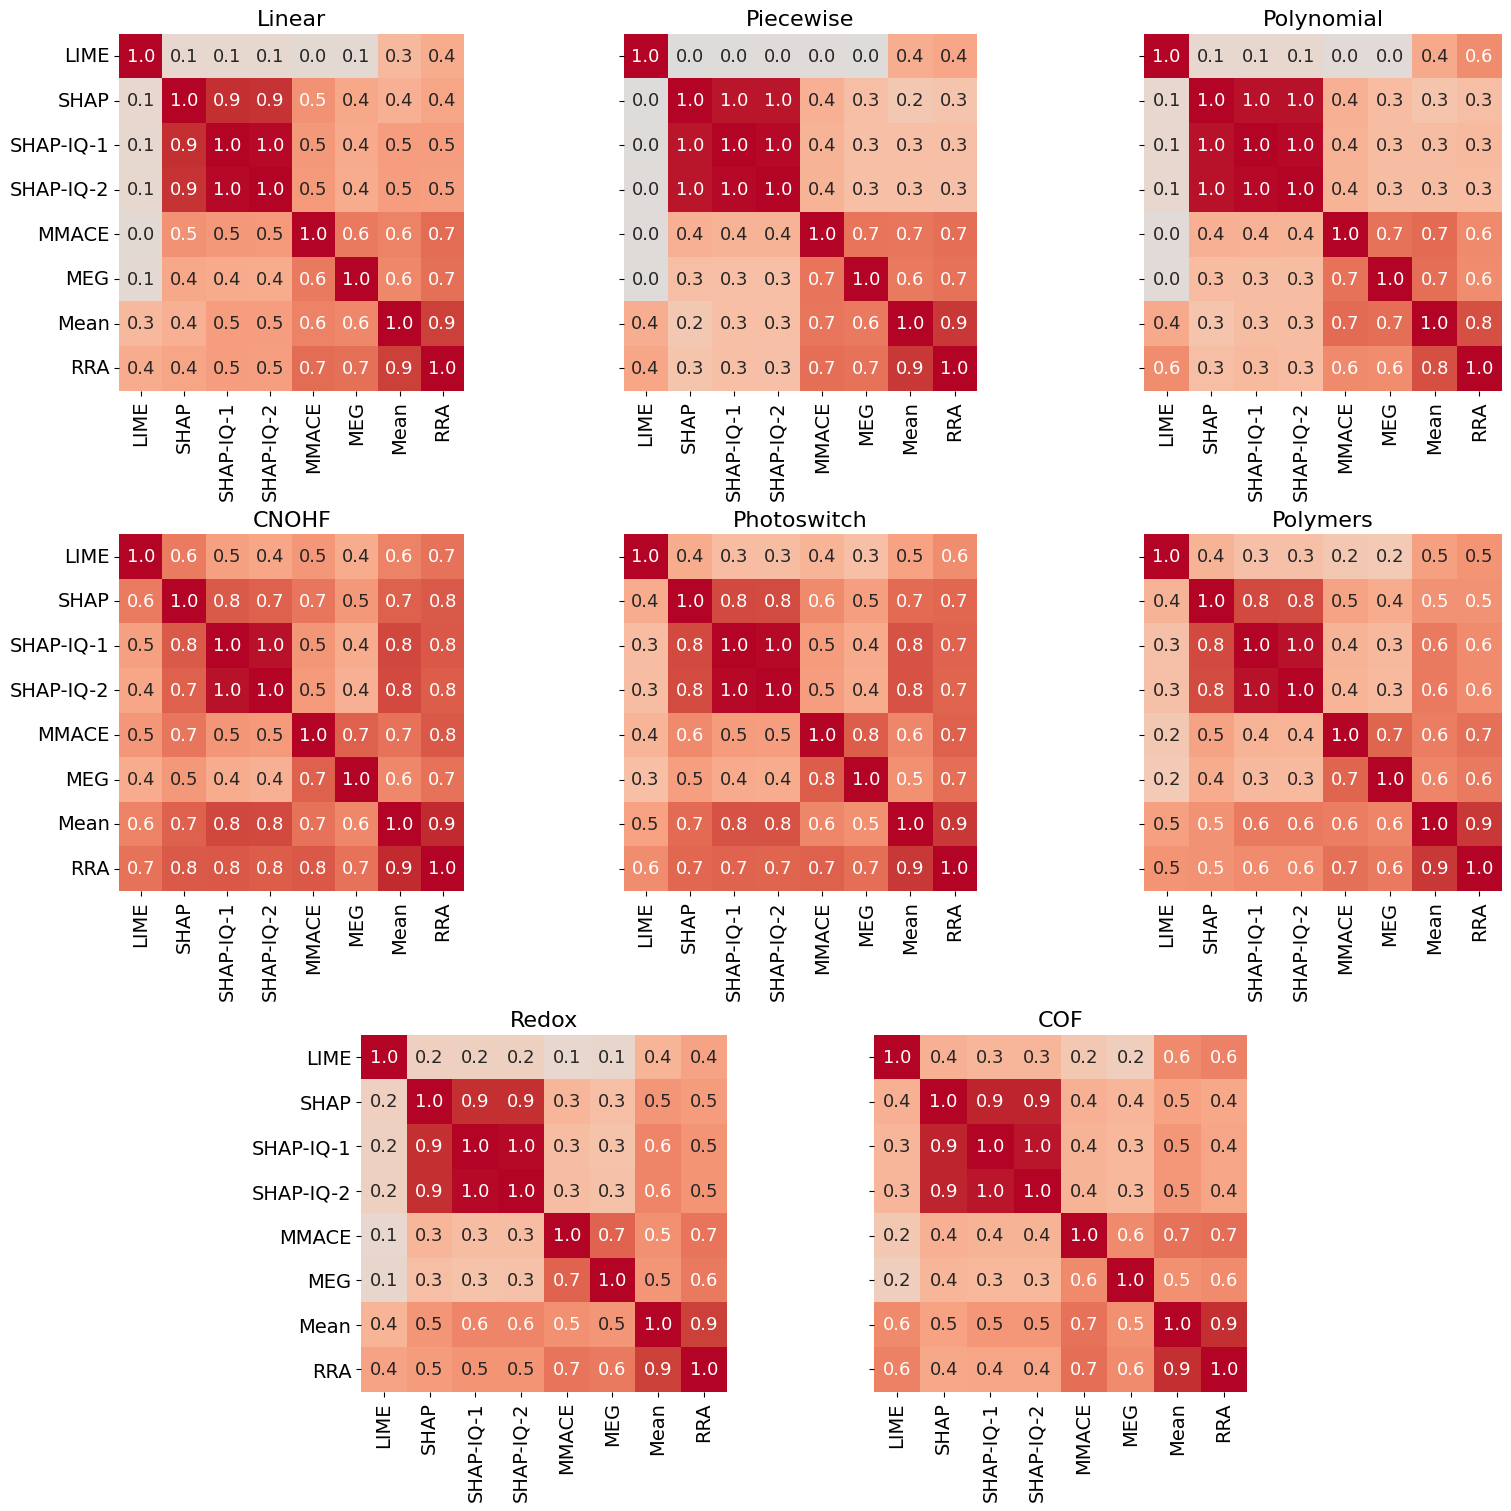

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

layout = [
        ["A", "A", "B", "B", "C", "C"],  # Row 1 (3 plots)
        ["D", "D", "E", "E", "F", "F"],  # Row 2 (3 plots)
        [".", "G", "G", "H", "H", "."]   # Row 3 (2 plots, centered)
    ]
axes_keys = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
fig, ax = plt.subplot_mosaic(layout, figsize=(15, 15), constrained_layout=True, sharey=True)
name_data_mapping = {
    'Linear': 'Linear',
    'Piecewise': 'Piecewise',
    'Polynomial': 'Polynomial',
    'CNOHF': 'CNOHF',
    'COF': 'COF',
    'Photoswitch': 'Photoswitch',
    'Polymers': 'Polymers',
    'Redox': 'Redox',
}
order_mapping = {
    'Linear': 0,
    'Piecewise': 1,
    'Polynomial': 2,
    'CNOHF': 3,
    'Photoswitch': 4,
    'Polymers': 5,
    'Redox': 6,
    'COF': 7,
}
methods_mapping = {
    'lime': 'LIME',
    'shap': 'SHAP',
    'shapiq1': 'SHAP-IQ-1',
    'shapiq2': 'SHAP-IQ-2',
    'meg': 'MEG',
    'mmace': 'MMACE',
    'aggregated_mean': 'Mean',
    'aggregated_rra': 'RRA'
}
methods_order = ['LIME', 'SHAP', 'SHAP-IQ-1', 'SHAP-IQ-2', 'MMACE', 'MEG', 'Mean', 'RRA']
plt.style.use('default')
for i, (key, data) in enumerate(rf_correlations.items()):
    if key not in name_data_mapping:
        continue
    s = pd.Series(data)
    correlation_matrix = s.unstack()
    renamed_matrix = correlation_matrix.rename(index=methods_mapping, columns=methods_mapping)
    display(renamed_matrix)
    renamed_matrix = renamed_matrix[methods_order].loc[methods_order]
    axes_id = axes_keys[order_mapping[key]]
    mappable = sns.heatmap(renamed_matrix, annot=True, fmt=".1f", ax=ax[axes_id], cmap='coolwarm', vmin=-1, vmax=1, cbar=False, annot_kws={'size': 13})

    ax[axes_id].set_title(name_data_mapping[key], fontsize=16)
    ax[axes_id].tick_params(axis='both', which='major', labelsize=14)

ax['G'].tick_params(axis='y', labelleft=True, rotation=0)

#plt.tight_layout()
plt.savefig('../results/correlation_matrices_rf.pdf', dpi=300, bbox_inches='tight')
plt.show()